<a href="https://colab.research.google.com/github/abbosaliboev/Computer_Vision/blob/main/8_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Environment

In [1]:
!pip install -U torchtext==0.6.0
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 105.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
!rm -rf .data multi30k* *.tar.gz

!mkdir -p .data/multi30k
!wget https://github.com/multi30k/dataset/archive/refs/heads/master.zip -O multi30k.zip
!unzip -q multi30k.zip -d .data/multi30k
!gunzip -f .data/multi30k/dataset-master/data/task1/raw/*.gz

!cp .data/multi30k/dataset-master/data/task1/raw/train.de .data/multi30k/train.de
!cp .data/multi30k/dataset-master/data/task1/raw/train.en .data/multi30k/train.en

!cp .data/multi30k/dataset-master/data/task1/raw/val.de .data/multi30k/val.de
!cp .data/multi30k/dataset-master/data/task1/raw/val.en .data/multi30k/val.en

!cp .data/multi30k/dataset-master/data/task1/raw/test_2016_flickr.de .data/multi30k/test2016.de
!cp .data/multi30k/dataset-master/data/task1/raw/test_2016_flickr.en .data/multi30k/test2016.en

--2026-05-08 01:06:52--  https://github.com/multi30k/dataset/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/multi30k/dataset/zip/refs/heads/master [following]
--2026-05-08 01:06:52--  https://codeload.github.com/multi30k/dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.116.10
Connecting to codeload.github.com (codeload.github.com)|140.82.116.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘multi30k.zip’

multi30k.zip            [         <=>        ]  17.34M  9.24MB/s    in 1.9s    

2026-05-08 01:06:54 (9.24 MB/s) - ‘multi30k.zip’ saved [18178902]



In [3]:
import torch
import torch.nn as nn

from torchtext.datasets import Multi30k
from torchtext.data import Field, BucketIterator

import spacy
import math
import time
import numpy as np
import matplotlib.pyplot as plt

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Seed
seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

### Dataset

Tokenizer

In [4]:
spacy_de = spacy.load('de_core_news_sm')
spacy_en = spacy.load('en_core_web_sm')

In [5]:
def tokenize_de(text):
  return [tok.text for tok in spacy_de.tokenizer(text)]

def tokenize_en(text):
  return [tok.text for tok in spacy_en.tokenizer(text)]

In [6]:
SRC = Field(
    tokenize=tokenize_de,
    init_token='<sos>',
    eos_token='<eos>',
    lower=True,
    batch_first=True
)
TRG = Field(
    tokenize=tokenize_en,
    init_token='<sos>',
    eos_token='<eos>',
    lower=True,
    batch_first=True
)

Split

In [7]:
train_data, val_data, test_data = Multi30k.splits(
    exts=('.de', '.en'),
    fields=(SRC, TRG)
)

print(len(train_data), len(val_data), len(test_data))

29000 1014 1000


In [8]:
# Number of data
print(f"Number of train data: {len(train_data.examples)}")
print(f"Number of val data: {len(val_data.examples)}")
print(f"Number of test data: {len(test_data.examples)}")

Number of train data: 29000
Number of val data: 1014
Number of test data: 1000


In [9]:
# Examples of data
examples = np.random.randint(len(train_data.examples), size=5)
for idx in examples:
  print(f"{vars(train_data.examples[idx])}")

{'src': ['eine', 'frau', 'in', 'roter', 'bluse', 'und', 'jeansrock', 'fotografiert', 'eine', 'skulptur', ',', 'die', 'von', 'bauzäunen', 'umgeben', 'ist', '.'], 'trg': ['a', 'woman', 'in', 'a', 'red', 'shirt', 'and', 'denim', 'skirt', 'takes', 'a', 'photograph', 'of', 'a', 'sculpture', 'that', 'is', 'surrounded', 'by', 'construction', 'fences', '.']}
{'src': ['zwei', 'kinder', 'spielen', 'an', 'einem', 'verschneiten', 'tag', 'auf', 'der', 'straße', '.'], 'trg': ['two', 'children', 'play', 'on', 'the', 'road', 'on', 'a', 'snowy', 'day', '.']}
{'src': ['leute', ',', 'die', 'auf', 'den', 'strand', 'schauen', ',', 'und', 'eine', 'frau', 'in', 'einem', 'weinroten', 'trägerhemd', ',', 'die', 'ein', 'foto', 'macht', '.'], 'trg': ['people', 'looking', 'at', 'the', 'beach', 'and', 'a', 'woman', 'in', 'a', 'wine', 'top', 'taking', 'a', 'picture', '.']}
{'src': ['drei', 'männer', 'mit', 'ohrschützern', 'halten', 'ein', 'gewehr', 'und', 'üben', 'auf', 'einem', 'schießplatz', 'schießen', '.'], 'trg

Vocabulary

In [10]:
SRC.build_vocab(train_data, min_freq = 2)
TRG.build_vocab(train_data, min_freq = 2)

In [11]:
# Vocabulary size
print(f"Source vocab size (de): {len(SRC.vocab)}")
print(f"Target vocab size (en): {len(TRG.vocab)}")

Source vocab size (de): 7853
Target vocab size (en): 5893


In [12]:
# Token index
print(f"<unk> token: {TRG.vocab.stoi['abc']}")
print(f"<pad> token: {TRG.vocab.stoi[TRG.pad_token]}")
print(f"<sos> token: {TRG.vocab.stoi['<sos>']}")
print(f"<eos> token: {TRG.vocab.stoi['<eos>']}")
print(f"happy: {TRG.vocab.stoi['happy']}")

<unk> token: 0
<pad> token: 1
<sos> token: 2
<eos> token: 3
happy: 667


Iterator

In [13]:
BATCH_SIZE = 256

train_iter, val_iter, test_iter = BucketIterator.splits(
    (train_data, val_data, test_data),
    batch_size=BATCH_SIZE,
    device=device
)

In [14]:
# Examples of input and output
for iter, batch in enumerate(train_iter):
    src = batch.src
    trg = batch.trg

    print(f"src: {src[0]}")
    print(f"trg: {trg[0]}\n")

    if iter == 2:
        break

src: tensor([  2,   8, 230,  38,  12,  14,  34,   9,   0, 144,  28,   4,   3,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1], device='cuda:0')
trg: tensor([  2,   4, 200,  37,   8,   4,  39,  58, 582, 201,   3,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1], device='cuda:0')

src: tensor([   2,    8,   16,   17,  160,   10,    5,  689,  120,   61,   69,   20,
          88,   27,   14, 1252,  545,    4,    3,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1], device='cuda:0')
trg: tensor([  2,   4,  14,  22, 175,  11,   4,  52, 208,  42,  23, 179,   6,  43,
         12,   4, 632, 443, 341,   5,   3,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1], device='cuda:0')

src: tensor([   2,    8,   67,    7,    6, 2178,   29,   12,    6,  194,    9,   39,
       

### Model

Multi-Head Attention

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__ (self, hidden_dim, n_heads, dropout):
        super(MultiHeadAttention, self).__init__()

        self.hidden_dim = hidden_dim
        self.n_heads = n_heads
        self.head_dim = hidden_dim // n_heads

        self.fc_q = nn.Linear(hidden_dim, hidden_dim)
        self.fc_k = nn.Linear(hidden_dim, hidden_dim)
        self.fc_v = nn.Linear(hidden_dim, hidden_dim)
        self.fc_o = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, query, key, value, mask=None):
        # Perform Multi-Head Attention with Scaled Dot-Product Attention.
        batch_size = query.size(0)

        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)

        # [batch_size x n_heads x q_len x head_dim]
        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)

        # [batch_size x n_heads x q_len x k_len]
        energy = torch.matmul(Q, K.transpose(2, 3)) / math.sqrt(self.head_dim)

        if mask is not None:
            energy = energy.masked_fill(mask==0, -1e10)

        attn = self.softmax(energy)
        attn = self.dropout(attn)

        # [batch_size x n_heads x q_len x head_dim]
        output = torch.matmul(attn, V)

        # [batch_size x q_len x hidden_dim]
        output = output.permute(0, 2, 1, 3).contiguous()
        output = output.view(batch_size, -1, self.n_heads * self.head_dim)

        # [batch_size x q_len x hidden_dim]
        output = self.fc_o(output)

        return output, attn

Position-wise Feed-Forward Network

In [16]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, hidden_dim, ffn_dim, dropout):
        super(PositionwiseFeedForward, self).__init__()

        self.fc_1 = nn.Linear(hidden_dim, ffn_dim)
        self.fc_2 = nn.Linear(ffn_dim, hidden_dim)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        #Perform Position-wise Feed-Forward Network.
        x = self.fc_1(x)
        x = self.dropout(self.relu(x))
        x = self.fc_2(x)

        return x

Positional Encoding

In [17]:
def PositionalEncoding(hidden_dim, seq_len):
    positional_encoding = torch.zeros((seq_len, hidden_dim))

    pos = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)

    _2i = torch.arange(0, hidden_dim, step=2, dtype=torch.float)

    positional_encoding[:, 0::2] = torch.sin(pos / (10000 ** (_2i / hidden_dim)))
    positional_encoding[:, 1::2] = torch.cos(pos / (10000 ** (_2i / hidden_dim)))

    pos_enc = positional_encoding.unsqueeze(0)

    return pos_enc

Encoder Layer

In [18]:
class EncoderLayer(nn.Module):
    def __init__(self, hidden_dim, n_heads, ffn_dim, dropout):
        super(EncoderLayer, self).__init__()

        self.self_attention = MultiHeadAttention(hidden_dim, n_heads, dropout)
        self.norm_1 = nn.LayerNorm(hidden_dim)

        self.ffn = PositionwiseFeedForward(hidden_dim, ffn_dim, dropout)
        self.norm_2 = nn.LayerNorm(hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-Attention
        _x, _ = self.self_attention(x, x, x, mask)
        x = self.norm_1(x + self.dropout(_x))

        # Feed Forward Network
        _x = self.ffn(x)
        x = self.norm_2(x + self.dropout(_x))

        return x

Encoder

In [19]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, n_heads, ffn_dim, max_len, dropout):
        super(Encoder, self).__init__()

        self.src_emb = nn.Embedding(input_dim, hidden_dim)

        self.hidden_dim = hidden_dim

        self.layers = nn.ModuleList([EncoderLayer(hidden_dim, n_heads, ffn_dim, dropout) for _ in range(n_layers)])

        self.dropout = nn.Dropout(dropout)

        self.scale = math.sqrt(hidden_dim)

    def forward(self, x, mask=None):
        batch_size, seq_len = x.size()

        pos_enc = PositionalEncoding(self.hidden_dim, seq_len).to(x.device)
        x = self.dropout((self.src_emb(x) * self.scale) + pos_enc)

        for layer in self.layers:
            x = layer(x, mask)

        return x

Decoder Layer

In [20]:
class DecoderLayer(nn.Module):
    def __init__(self, hidden_dim, n_heads, ffn_dim, dropout):
        super(DecoderLayer, self).__init__()

        self.self_attention = MultiHeadAttention(hidden_dim, n_heads, dropout)
        self.norm_1 = nn.LayerNorm(hidden_dim)

        self.enc_dec_attention = MultiHeadAttention(hidden_dim, n_heads, dropout)
        self.norm_2 = nn.LayerNorm(hidden_dim)

        self.ffn = PositionwiseFeedForward(hidden_dim, ffn_dim, dropout)
        self.norm_3 = nn.LayerNorm(hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, trg_mask=None, src_mask=None):
        # Self-Attention
        _x, _ = self.self_attention(x, x, x, trg_mask)
        x = self.norm_1(x + self.dropout(_x))

        # Encoder-Decoder Attention
        _x, attn = self.enc_dec_attention(x, enc_output, enc_output, src_mask)
        x = self.norm_2(x + self.dropout(_x))

        # Feed Forward Network
        _x = self.ffn(x)
        x = self.norm_3(x + self.dropout(_x))

        return x, attn

Decoder

In [21]:
class Decoder(nn.Module):
    def __init__(self, output_dim, hidden_dim, n_layers, n_heads, ffn_dim, max_len, dropout):
        super(Decoder, self).__init__()

        self.trg_emb = nn.Embedding(output_dim, hidden_dim)

        self.hidden_dim = hidden_dim

        self.layers = nn.ModuleList([DecoderLayer(hidden_dim, n_heads, ffn_dim, dropout) for _ in range(n_layers)])

        self.fc_out = nn.Linear(hidden_dim, output_dim)

        self.dropout = nn.Dropout(dropout)

        self.scale = math.sqrt(hidden_dim)

    def forward(self, x, enc_output, trg_mask=None, src_mask=None):
        batch_size, seq_len = x.size()

        pos_enc = PositionalEncoding(self.hidden_dim, seq_len).to(x.device)
        x = self.dropout((self.trg_emb(x) * self.scale) + pos_enc)

        for layer in self.layers:
            x, attn = layer(x, enc_output, trg_mask, src_mask)

        output = self.fc_out(x)

        return output, attn

Transformer

In [22]:
class Transformer(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, n_layers, n_heads, ffn_dim, max_len, dropout, src_pad_idx, trg_pad_idx, device):
        super(Transformer, self).__init__()

        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx

        self.device = device

        self.encoder = Encoder(input_dim, hidden_dim, n_layers, n_heads, ffn_dim, max_len, dropout)
        self.decoder = Decoder(output_dim, hidden_dim, n_layers, n_heads, ffn_dim, max_len, dropout)

    def pad_mask(self, src, trg, src_pad_idx, trg_pad_idx):
        src_mask = (src != src_pad_idx).unsqueeze(1).unsqueeze(2)
        trg_mask = (trg != trg_pad_idx).unsqueeze(1).unsqueeze(3)
        trg_mask = trg_mask & self.subsequent_mask(trg_mask.shape[2])
        return src_mask, trg_mask

    def subsequent_mask(self, seq_len):
        sub_mask = torch.tril(torch.ones((seq_len, seq_len), dtype=torch.long)).to(self.device)
        return sub_mask

    def forward(self, src, trg):
        src_mask, trg_mask = self.pad_mask(src, trg, self.src_pad_idx, self.trg_pad_idx)

        enc_output = self.encoder(src, mask=src_mask)
        output, attn = self.decoder(trg, enc_output, trg_mask=trg_mask, src_mask=src_mask)

        return output, attn

### Training

Hyperparameter

In [23]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
MAX_LEN = 100

SRC_PAD_IDX = SRC.vocab.stoi[SRC.pad_token]
TRG_PAD_IDX = TRG.vocab.stoi[TRG.pad_token]

# Tune
HIDDEN_DIM = 256
N_LAYERS = 3
N_HEADS = 4
FFN_DIM = 1024
DROPOUT = 0.1

In [24]:
# Tune
EPOCH = 15
LEARNING_RATE = 5e-4

Utils

In [25]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def initialize_weights(model):
    if hasattr(model, 'weight') and model.weight.dim() > 1:
        nn.init.xavier_uniform_(model.weight.data)

def idx_to_word(token, vocab):
    sentence = []
    for t in token:
        if t > 3:
            sentence.append(vocab.itos[t])

    return sentence

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))

    return elapsed_mins, elapsed_secs

Train

In [26]:
def train(model, train_iter, optimizer, criterion):
    model.train()
    train_loss = 0
    for _, batch in enumerate(train_iter):
        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output, _ = model(src, trg[:,:-1])
        output = output.contiguous().view(-1, output.shape[-1])
        trg = trg[:,1:].contiguous().view(-1)

        loss = criterion(output, trg)
        train_loss += loss.item() / len(train_iter)

        loss.backward()
        optimizer.step()

    return train_loss

Evaluation

In [27]:
def eval(model, eval_iter, criterion):
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for _, batch in enumerate(eval_iter):
            src = batch.src
            trg = batch.trg

            output, _ = model(src, trg[:,:-1])
            output = output.contiguous().view(-1, output.shape[-1])
            trg = trg[:,1:].contiguous().view(-1)

            loss = criterion(output, trg)
            eval_loss += loss.item() / len(eval_iter)

    return eval_loss

Train & Val

In [28]:
model = Transformer(
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    ffn_dim=FFN_DIM,
    max_len=MAX_LEN,
    dropout=DROPOUT,
    src_pad_idx=SRC_PAD_IDX,
    trg_pad_idx=TRG_PAD_IDX,
    device=device
).to(device)

print(f"The model has {count_parameters(model):,} trainable parameters.")

model.apply(initialize_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)

The model has 10,563,077 trainable parameters.


In [29]:
# Train & Val
best_loss = 999.
for epoch in range(EPOCH):
    start_time = time.time()

    train_loss = train(model, train_iter, optimizer, criterion)
    val_loss = eval(model, val_iter, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(f"Epoch: {epoch+1} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
    print(f"\tVal Loss: {val_loss:.3f} | Val PPL: {math.exp(val_loss):7.3f}")

Epoch: 1 | Time: 0m 15s
	Train Loss: 5.212 | Train PPL: 183.403
	Val Loss: 3.968 | Val PPL:  52.880
Epoch: 2 | Time: 0m 15s
	Train Loss: 3.751 | Train PPL:  42.543
	Val Loss: 3.237 | Val PPL:  25.456
Epoch: 3 | Time: 0m 15s
	Train Loss: 3.073 | Train PPL:  21.602
	Val Loss: 2.551 | Val PPL:  12.823
Epoch: 4 | Time: 0m 15s
	Train Loss: 2.505 | Train PPL:  12.246
	Val Loss: 2.173 | Val PPL:   8.789
Epoch: 5 | Time: 0m 15s
	Train Loss: 2.136 | Train PPL:   8.464
	Val Loss: 1.929 | Val PPL:   6.883
Epoch: 6 | Time: 0m 15s
	Train Loss: 1.874 | Train PPL:   6.514
	Val Loss: 1.799 | Val PPL:   6.046
Epoch: 7 | Time: 0m 15s
	Train Loss: 1.674 | Train PPL:   5.332
	Val Loss: 1.711 | Val PPL:   5.537
Epoch: 8 | Time: 0m 16s
	Train Loss: 1.519 | Train PPL:   4.566
	Val Loss: 1.636 | Val PPL:   5.132
Epoch: 9 | Time: 0m 16s
	Train Loss: 1.390 | Train PPL:   4.014
	Val Loss: 1.580 | Val PPL:   4.853
Epoch: 10 | Time: 0m 16s
	Train Loss: 1.281 | Train PPL:   3.600
	Val Loss: 1.570 | Val PPL:   4.805

Test

In [30]:
# Test
model.load_state_dict(torch.load('best_model.pt'))
model.to(device)

Transformer(
  (encoder): Encoder(
    (src_emb): Embedding(7853, 256)
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (fc_q): Linear(in_features=256, out_features=256, bias=True)
          (fc_k): Linear(in_features=256, out_features=256, bias=True)
          (fc_v): Linear(in_features=256, out_features=256, bias=True)
          (fc_o): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (softmax): Softmax(dim=-1)
        )
        (norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (ffn): PositionwiseFeedForward(
          (fc_1): Linear(in_features=256, out_features=1024, bias=True)
          (fc_2): Linear(in_features=1024, out_features=256, bias=True)
          (relu): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0

In [31]:
# Test
test_loss = eval(model, test_iter, criterion)
print(f"\tTest Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f}")

	Test Loss: 1.620 | Test PPL:   5.053


### Inference

Translation

In [32]:
def machine_translation(sentence, SRC, TRG, model, device, max_len=50):
    model.eval()

    if isinstance(sentence, list):
      sentence = " ".join(sentence)
      token = tokenize_de(sentence)
      token = [SRC.init_token] + token + [SRC.eos_token]

      src = [SRC.vocab.stoi[tok] for tok in token]
      src = torch.tensor(src, dtype=torch.long).unsqueeze(0).to(device)
    else:
      src = sentence.unsqueeze(0)

    src_mask = (src != model.src_pad_idx).unsqueeze(1).unsqueeze(2)

    with torch.no_grad():
        enc_output = model.encoder(src, mask=src_mask)

    trg_idx = [TRG.vocab.stoi[TRG.init_token]]
    trg_idx = torch.tensor(trg_idx, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_len):
        trg_mask = (trg_idx != model.trg_pad_idx).unsqueeze(1).unsqueeze(3)
        trg_mask = trg_mask & model.subsequent_mask(trg_mask.shape[2])

        with torch.no_grad():
            output, attn = model.decoder(trg_idx, enc_output, trg_mask=trg_mask, src_mask=src_mask)

        pred = output.argmax(dim=-1)
        pred = pred[:,-1].unsqueeze(1)

        trg_idx = torch.cat((trg_idx, pred), dim=-1)

        if pred == TRG.vocab.stoi[TRG.eos_token]:
            break

    trg_idx = trg_idx.squeeze(0)
    translate = [TRG.vocab.itos[t] for t in trg_idx]

    return translate, attn

BLEU score

In [33]:
from torchtext.data.metrics import bleu_score

def calculate_score(test_iter, SRC, TRG, model, device):
    preds, trgs = [], []

    for batch in test_iter:
        src = batch.src
        trg = batch.trg

        for j in range(len(batch)):
            pred, _ = machine_translation(src[j], SRC, TRG, model, device)
            preds.append(pred[1:-1])
            trg_word = idx_to_word(trg[j], TRG.vocab)
            trgs.append([trg_word])

    bleu = bleu_score(preds, trgs)

    return bleu

In [34]:
# BLEU score
bleu_score = calculate_score(test_iter, SRC, TRG, model, device)
print(f"BLEU score: {bleu_score*100:.2f}")

BLEU score: 38.54


## Visualization

Attention score

In [35]:
def visualize_attention(src, translate, attn, n_heads=8, n_rows=4, n_cols=2):
    assert n_rows * n_cols == n_heads

    fig = plt.figure(figsize=(n_cols*8, n_rows*8))
    fig.suptitle(f"Attention Score", fontsize=16)

    for i in range(n_heads):
        # i = head
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        ax.set_title(f"Head {i+1}", fontsize=16, pad=25)

        att = attn.squeeze(0)[i].cpu().detach().numpy()

        a = ax.matshow(att, cmap='Blues', aspect="auto")

        ax.tick_params(labelsize=12)
        ax.set_xticks(np.arange(len(src)+2))
        ax.set_yticks(np.arange(len(translate[:-1])))
        ax.set_xticklabels(['<sos>'] + src + ['<eos>'], rotation=45)
        ax.set_yticklabels(translate[:-1])

        cbar = fig.colorbar(a, ax=ax)

    plt.tight_layout()
    plt.show()
    plt.close()

src: ['ein', 'älterer', 'mann', 'spielt', 'ein', 'videospiel', '.']
trg: ['an', 'older', 'man', 'is', 'playing', 'a', 'video', 'arcade', 'game', '.']
translate: ['<sos>', 'an', 'older', 'man', 'playing', 'a', 'video', 'game', '.', '<eos>']


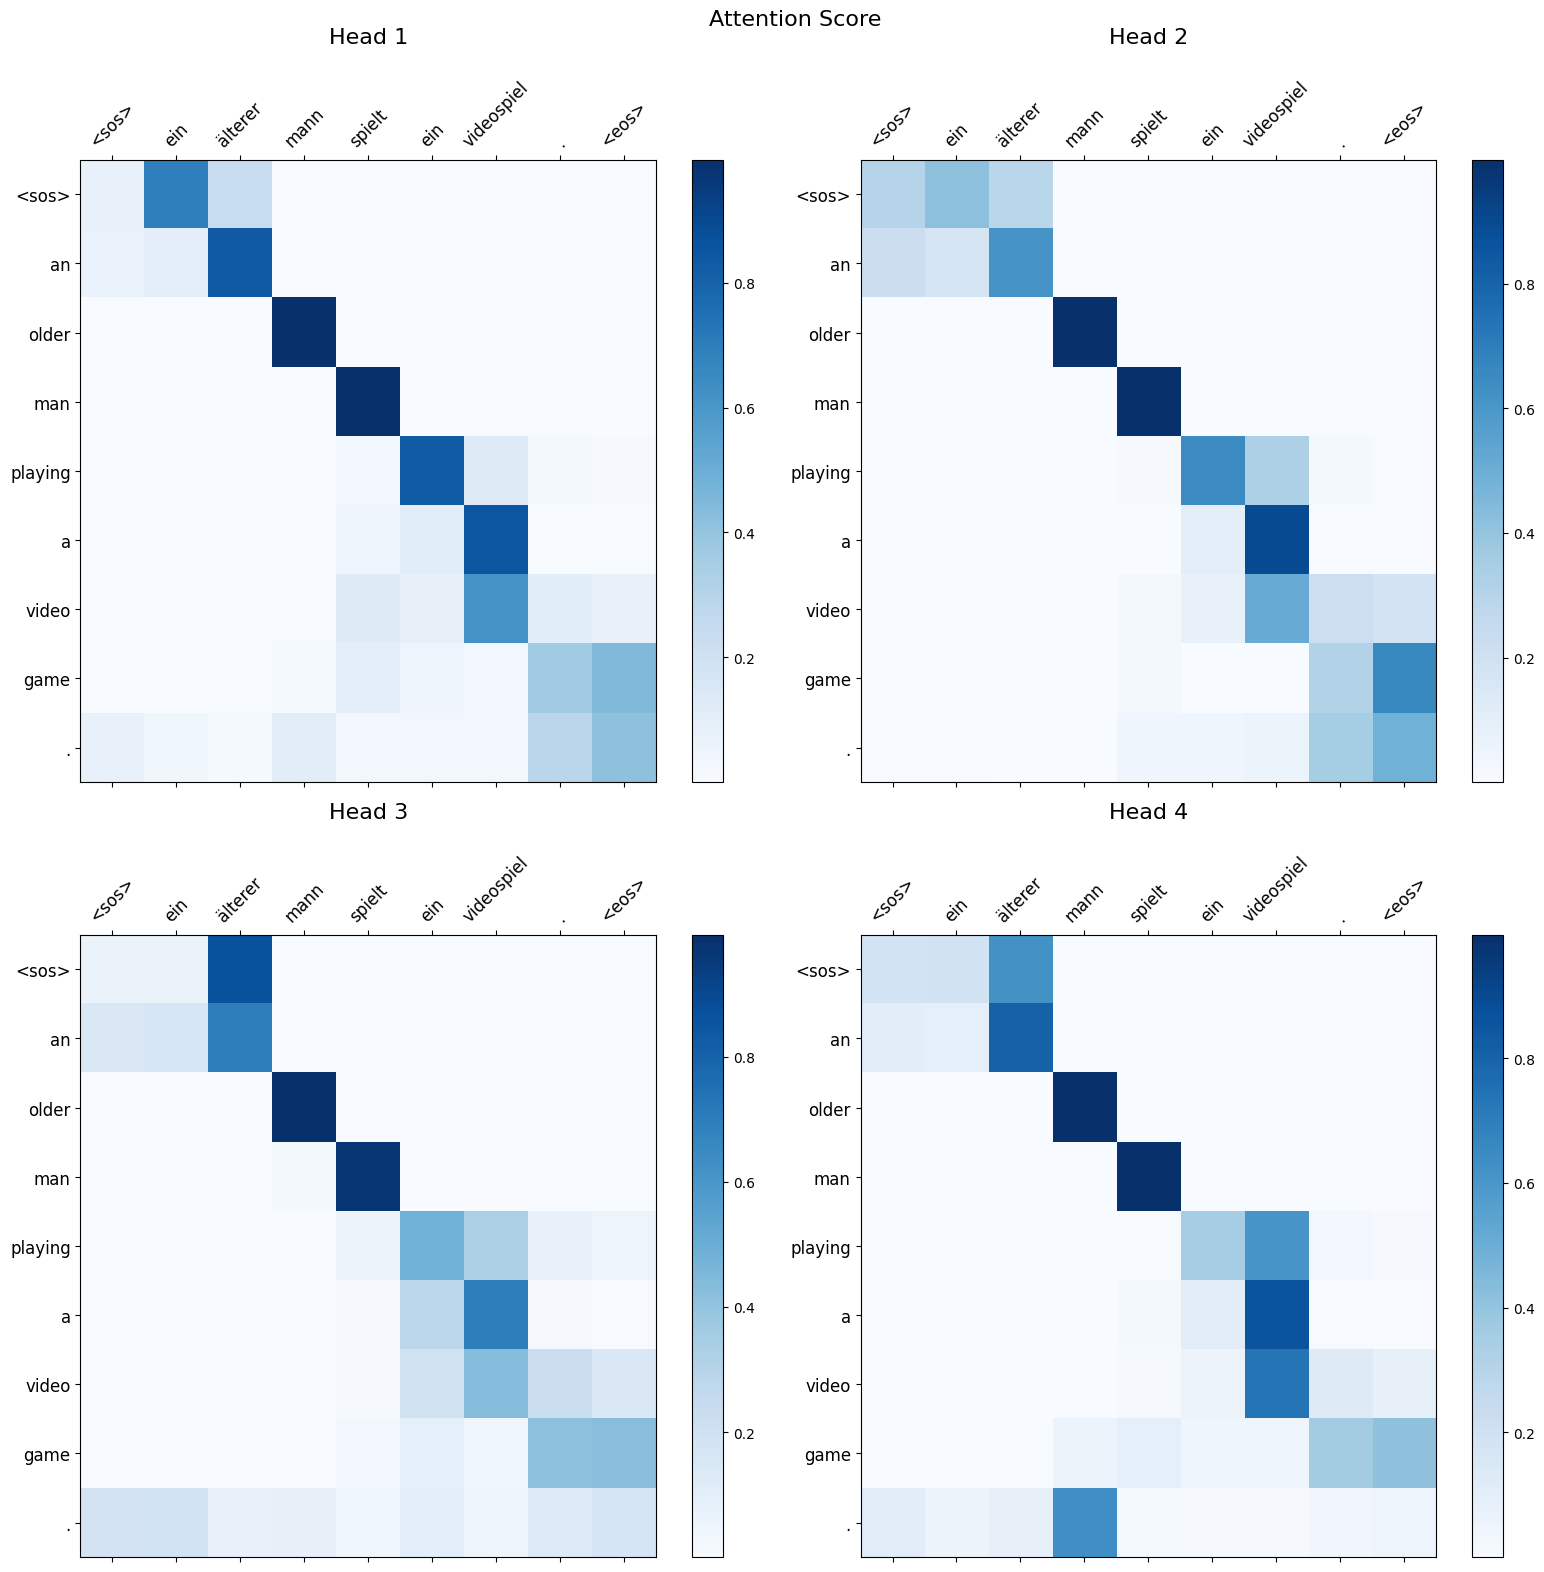

In [36]:
# Attention score
idx = 998 # random

src = vars(test_data.examples[idx])['src']
trg = vars(test_data.examples[idx])['trg']

print(f"src: {src}")
print(f"trg: {trg}")

translate, attn = machine_translation(src, SRC, TRG, model, device)
print(f"translate: {translate}")
visualize_attention(src, translate, attn, N_HEADS, 2, N_HEADS // 2)